In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()   # click "Choose Files" and upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"santoshvihar","key":"d0ce09507effabd733247b24f0315f0e"}'}

In [ ]:
# create credential directory, move the file, and secure it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
# download dataset zip to current working directory
!kaggle datasets download -d shiivvvaam/indian-districts-population-data


Dataset URL: https://www.kaggle.com/datasets/shiivvvaam/indian-districts-population-data
License(s): CC0-1.0
  0% 0.00/46.2k [00:00<?, ?B/s]
100% 46.2k/46.2k [00:00<00:00, 238MB/s]


In [ ]:
!unzip -q indian-districts-population-data.zip -d indian_districts_dataset
# list files
!ls -la indian_districts_dataset


total 228
drwxr-xr-x 2 root root   4096 Nov  2 05:38 .
drwxr-xr-x 1 root root   4096 Nov  2 05:38 ..
-rw-r--r-- 1 root root  40756 Feb  4  2024 census2011.csv
-rw-r--r-- 1 root root 184224 Feb  4  2024 census2011.xlsx


In [ ]:
import pandas as pd
df = pd.read_csv('indian_districts_dataset/census2011.csv')
display(df.head())
display(df.shape)

,Ranking,District,State,Population,Growth,Sex-Ratio,Literacy
0,1,Thane,Maharashtra,"11,060,148",36.01 %,886,84.53
1,2,North Twenty Four Parganas,West Bengal,"10,009,781",12.04 %,955,84.06
2,3,Bangalore,Karnataka,"9,621,551",47.18 %,916,87.67
3,4,Pune,Maharashtra,"9,429,408",30.37 %,915,86.15
4,5,Mumbai Suburban,Maharashtra,"9,356,962",8.29 %,860,89.91


(610, 7)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

In [ ]:
# Load dataset
df = pd.read_csv('indian_districts_dataset/census2011.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (610, 7)


,Ranking,District,State,Population,Growth,Sex-Ratio,Literacy
0,1,Thane,Maharashtra,"11,060,148",36.01 %,886,84.53
1,2,North Twenty Four Parganas,West Bengal,"10,009,781",12.04 %,955,84.06
2,3,Bangalore,Karnataka,"9,621,551",47.18 %,916,87.67
3,4,Pune,Maharashtra,"9,429,408",30.37 %,915,86.15
4,5,Mumbai Suburban,Maharashtra,"9,356,962",8.29 %,860,89.91


In [ ]:
df.isnull().sum()
df = df.dropna()

cols = ['Population', 'Growth', 'Sex-Ratio', 'Literacy']
data = df[cols].copy()
data.head()

,Population,Growth,Sex-Ratio,Literacy
0,"11,060,148",36.01 %,886,84.53
1,"10,009,781",12.04 %,955,84.06
2,"9,621,551",47.18 %,916,87.67
3,"9,429,408",30.37 %,915,86.15
4,"9,356,962",8.29 %,860,89.91


Task 1 – Linear Regression using Gradient Descent

In [ ]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

n = len(data)
train_end = int(0.7*n)
val_end   = int(0.85*n)

train = data.iloc[:train_end]
val   = data.iloc[train_end:val_end]
test  = data.iloc[val_end:]

print(len(train), len(val), len(test))


427 91 92


In [23]:
X_train = train[['Population', 'Growth', 'Sex-Ratio']].copy()
y_train = train['Literacy'].copy()

X_val = val[['Population', 'Growth', 'Sex-Ratio']].copy()
y_val = val['Literacy'].copy()

X_test = test[['Population', 'Growth', 'Sex-Ratio']].copy()
y_test = test['Literacy'].copy()

# Clean 'Population' and 'Growth' columns and convert to numeric
def clean_numeric_columns(df):
    df['Population'] = df['Population'].astype(str).str.replace(',', '', regex=False)
    df['Growth'] = df['Growth'].astype(str).str.replace('%', '', regex=False)
    df['Population'] = pd.to_numeric(df['Population'])
    df['Growth'] = pd.to_numeric(df['Growth'])
    return df

X_train = clean_numeric_columns(X_train)
X_val = clean_numeric_columns(X_val)
X_test = clean_numeric_columns(X_test)

# Normalize features for faster convergence
def normalize(X):
    # Handle potential division by zero for columns with zero standard deviation
    std_dev = X.std(axis=0)
    mean = X.mean(axis=0)
    # Replace 0 standard deviations with a small number to avoid division by zero
    std_dev[std_dev == 0] = 1e-9
    return (X - mean) / std_dev

X_train = normalize(X_train)
X_val   = normalize(X_val)
X_test  = normalize(X_test)

# Convert back to numpy arrays after cleaning and normalization
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values

y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

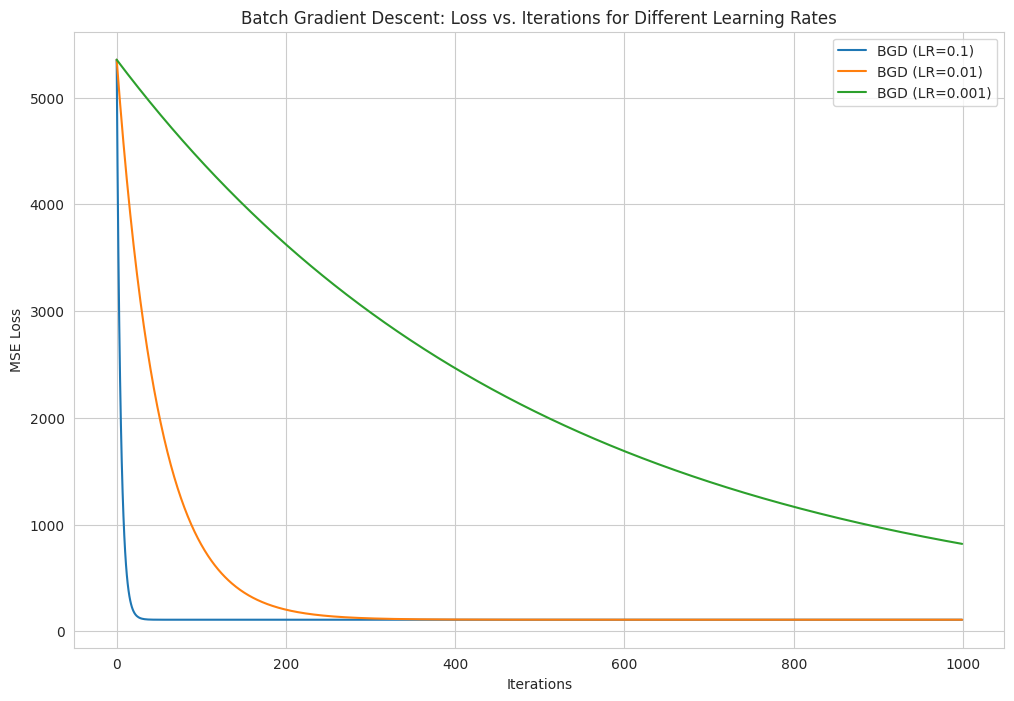

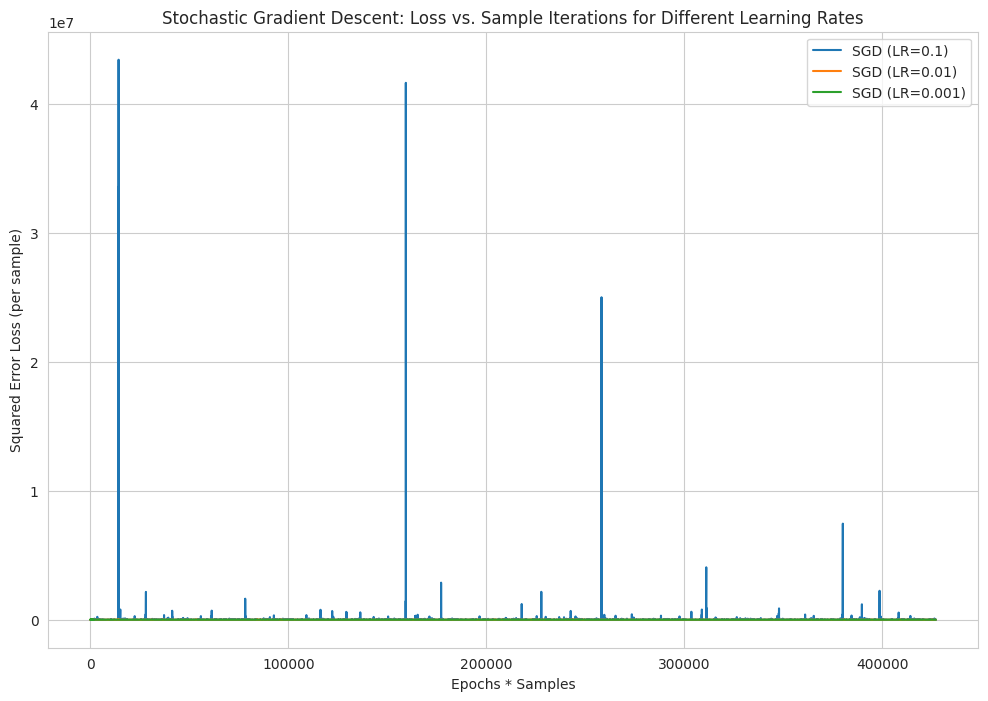

In [32]:
learning_rates = [0.1, 0.01, 0.001]
iterations = 1000

plt.figure(figsize=(12, 8))

# Batch Gradient Descent
for lr in learning_rates:
    bgd_model_lr = BatchGradientDescent(learning_rate=lr, iterations=iterations)
    bgd_model_lr.fit(X_train, y_train)
    plt.plot(bgd_model_lr.loss_history, label=f'BGD (LR={lr})')

plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: Loss vs. Iterations for Different Learning Rates")
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))

# Stochastic Gradient Descent
for lr in learning_rates:
    sgd_model_lr = StochasticGradientDescent(learning_rate=lr, iterations=iterations)
    sgd_model_lr.fit(X_train, y_train)
    plt.plot(sgd_model_lr.loss_history, label=f'SGD (LR={lr})')

plt.xlabel("Epochs * Samples") # Note: SGD updates weights per sample
plt.ylabel("Squared Error Loss (per sample)")
plt.title("Stochastic Gradient Descent: Loss vs. Sample Iterations for Different Learning Rates")
plt.legend()
plt.show()

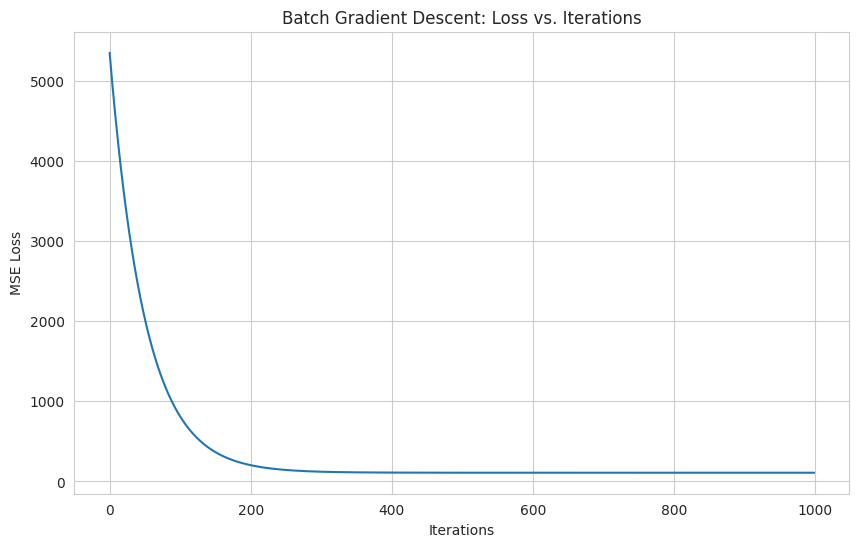

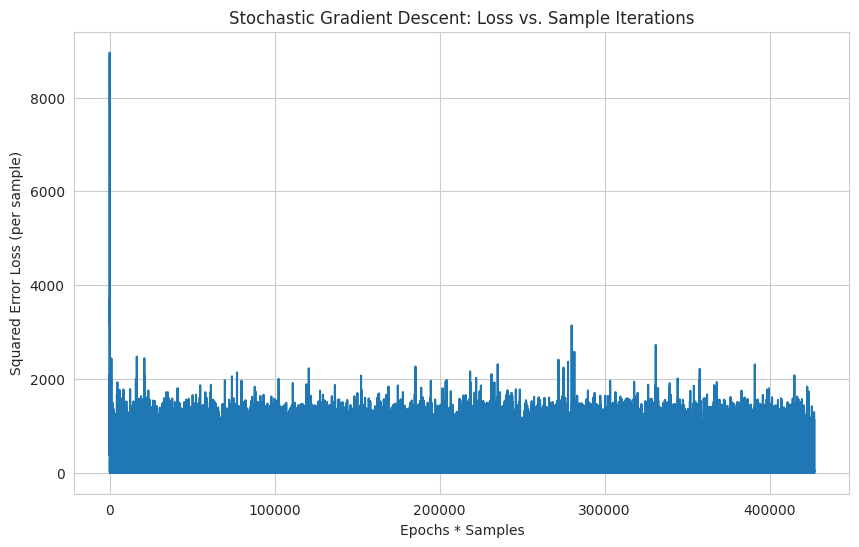

In [31]:
# Convergence plot for Batch Gradient Descent
plt.figure(figsize=(10, 6))
plt.plot(bgd_model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: Loss vs. Iterations")
plt.show()

# Convergence plot for Stochastic Gradient Descent
plt.figure(figsize=(10, 6))
plt.plot(sgd_model.loss_history)
plt.xlabel("Epochs * Samples") # Note: SGD updates weights per sample, so iterations are more granular
plt.ylabel("Squared Error Loss (per sample)")
plt.title("Stochastic Gradient Descent: Loss vs. Sample Iterations")
plt.show()

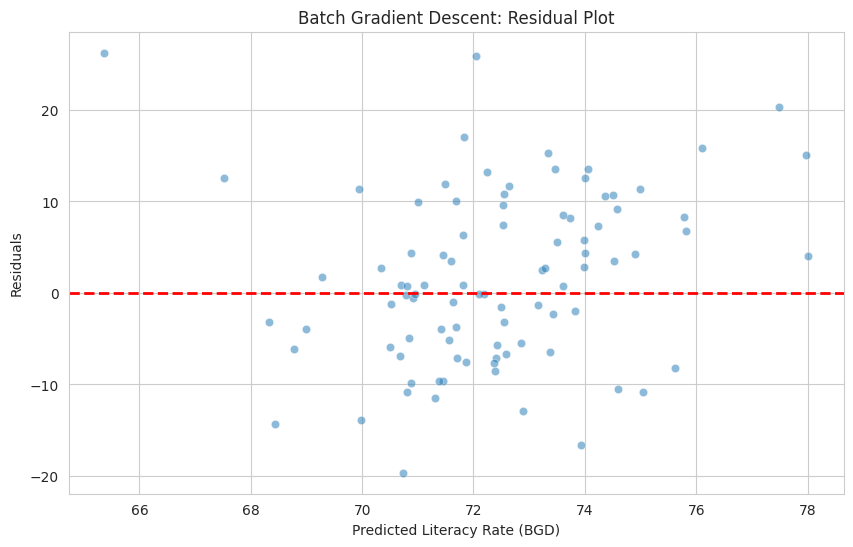

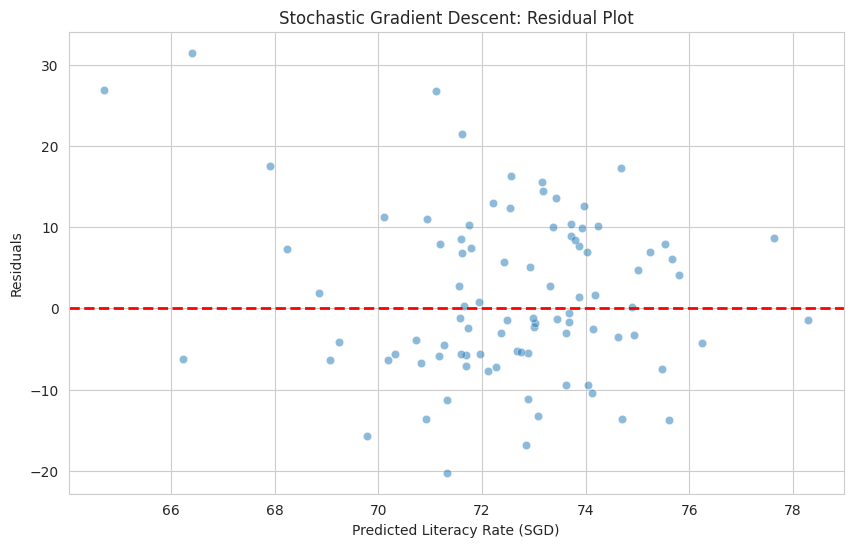

In [30]:
# Residual plot for Batch Gradient Descent
residuals_bgd = y_test - y_pred_bgd
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_bgd, y=residuals_bgd, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted Literacy Rate (BGD)")
plt.ylabel("Residuals")
plt.title("Batch Gradient Descent: Residual Plot")
plt.show()

# Residual plot for Stochastic Gradient Descent
residuals_sgd = y_test - y_pred_sgd
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_sgd, y=residuals_sgd, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted Literacy Rate (SGD)")
plt.ylabel("Residuals")
plt.title("Stochastic Gradient Descent: Residual Plot")
plt.show()

In [28]:
# Train the Stochastic Gradient Descent model
sgd_model = StochasticGradientDescent(learning_rate=0.01, iterations=1000)
sgd_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_sgd = sgd_model.predict(X_test)

# Evaluate the model
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("Stochastic Gradient Descent Evaluation:")
print(f"  MSE: {mse_sgd:.4f}")
print(f"  RMSE: {rmse_sgd:.4f}")
print(f"  MAE: {mae_sgd:.4f}")
print(f"  R2 Score: {r2_sgd:.4f}")

Stochastic Gradient Descent Evaluation:
  MSE: 103.4620
  RMSE: 10.1716
  MAE: 8.1432
  R2 Score: -0.0356


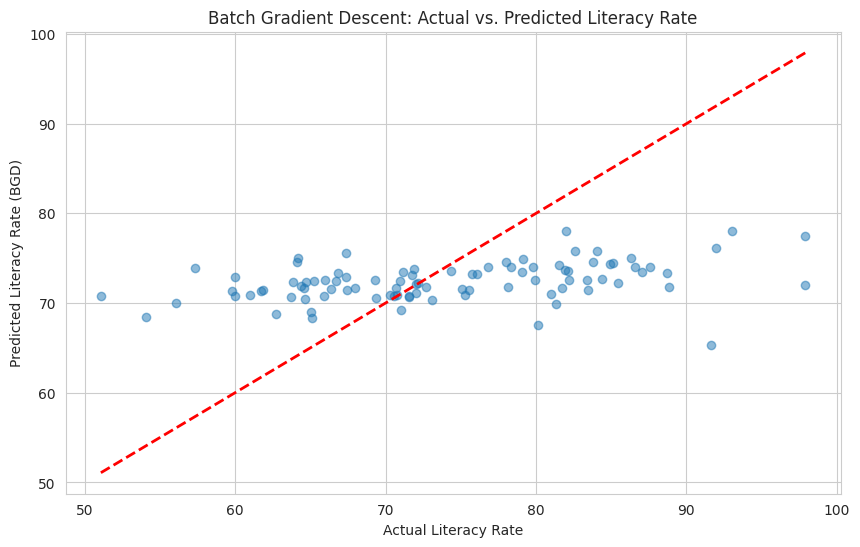

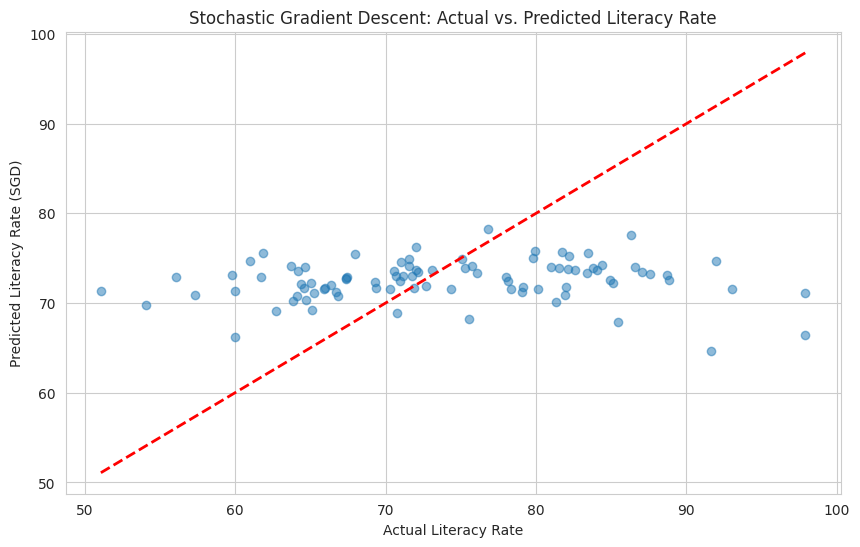

In [29]:
# Predicted vs. actual values scatter plot for Batch Gradient Descent
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_bgd, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate (BGD)")
plt.title("Batch Gradient Descent: Actual vs. Predicted Literacy Rate")
plt.show()

# Predicted vs. actual values scatter plot for Stochastic Gradient Descent
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_sgd, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate (SGD)")
plt.title("Stochastic Gradient Descent: Actual vs. Predicted Literacy Rate")
plt.show()

In [33]:
# Train the Stochastic Gradient Descent model
sgd_model = StochasticGradientDescent(learning_rate=0.01, iterations=1000)
sgd_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_sgd = sgd_model.predict(X_test)

# Evaluate the model
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print("Stochastic Gradient Descent Evaluation:")
print(f"  MSE: {mse_sgd:.4f}")
print(f"  RMSE: {rmse_sgd:.4f}")
print(f"  MAE: {mae_sgd:.4f}")
print(f"  R2 Score: {r2_sgd:.4f}")

Stochastic Gradient Descent Evaluation:
  MSE: 95.0111
  RMSE: 9.7474
  MAE: 8.0825
  R2 Score: 0.0490


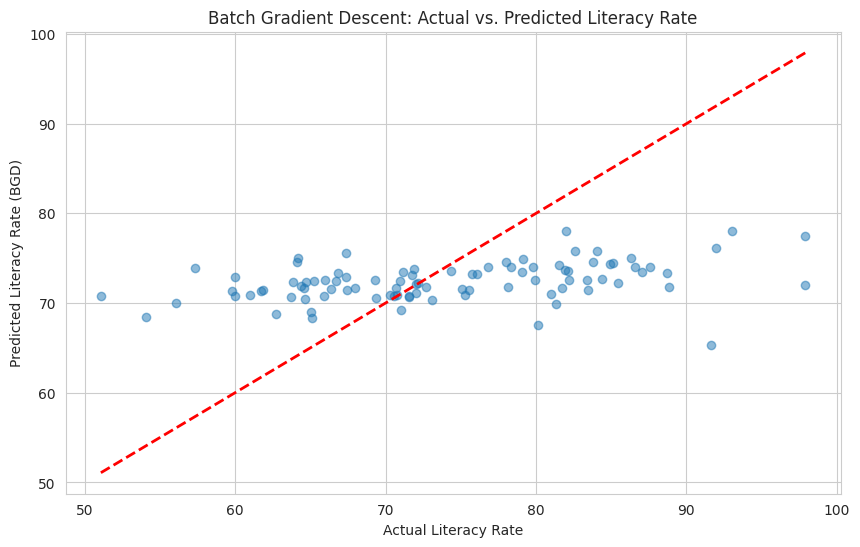

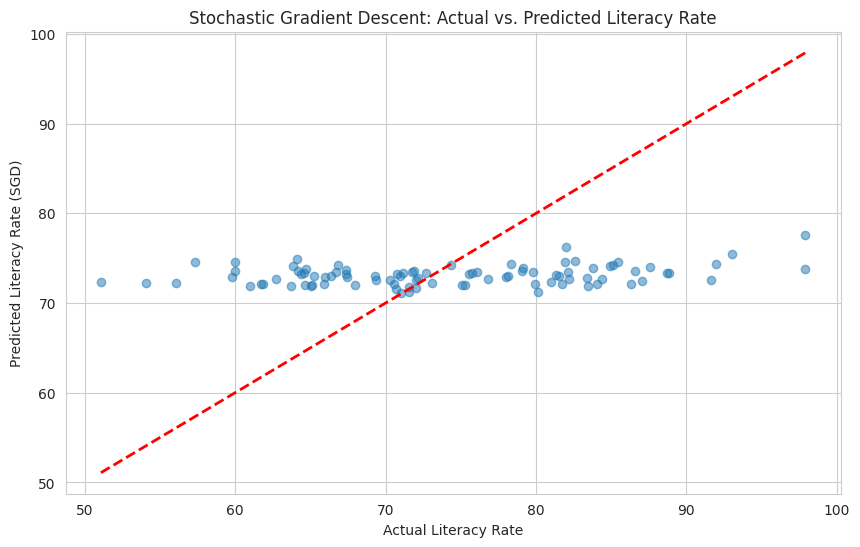

In [34]:
# Predicted vs. actual values scatter plot for Batch Gradient Descent
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_bgd, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate (BGD)")
plt.title("Batch Gradient Descent: Actual vs. Predicted Literacy Rate")
plt.show()

# Predicted vs. actual values scatter plot for Stochastic Gradient Descent
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_sgd, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate (SGD)")
plt.title("Stochastic Gradient Descent: Actual vs. Predicted Literacy Rate")
plt.show()

Task 2 heading

### Subtask:
Add a markdown cell to clearly mark the beginning of Task 2.


In [35]:
```markdown
## Task 2 – K-Nearest Neighbors from Scratch

SyntaxError: invalid syntax (ipython-input-4212879513.py, line 1)

In [36]:
def categorize_literacy(literacy_rate):
    """Categorizes literacy rate into Low, Medium, or High."""
    if literacy_rate < 60:
        return 'Low'
    elif 60 <= literacy_rate < 80:
        return 'Medium'
    else:
        return 'High'

df['Literacy_Category'] = df['Literacy'].apply(categorize_literacy)

display(df.head())
display(df['Literacy_Category'].value_counts())

,Ranking,District,State,Population,Growth,Sex-Ratio,Literacy,Literacy_Category
0,1,Thane,Maharashtra,"11,060,148",36.01 %,886,84.53,High
1,2,North Twenty Four Parganas,West Bengal,"10,009,781",12.04 %,955,84.06,High
2,3,Bangalore,Karnataka,"9,621,551",47.18 %,916,87.67,High
3,4,Pune,Maharashtra,"9,429,408",30.37 %,915,86.15,High
4,5,Mumbai Suburban,Maharashtra,"9,356,962",8.29 %,860,89.91,High


,count
Literacy_Category,
Medium,382
High,153
Low,75


In [37]:
from sklearn.model_selection import train_test_split

X_knn = df[['Population', 'Growth', 'Sex-Ratio']].copy()
y_knn = df['Literacy_Category'].copy()

# Clean 'Population' and 'Growth' columns and convert to numeric
def clean_numeric_columns_knn(df_knn):
    df_knn['Population'] = df_knn['Population'].astype(str).str.replace(',', '', regex=False)
    df_knn['Growth'] = df_knn['Growth'].astype(str).str.replace('%', '', regex=False)
    df_knn['Population'] = pd.to_numeric(df_knn['Population'])
    df_knn['Growth'] = pd.to_numeric(df_knn['Growth'])
    return df_knn

X_knn = clean_numeric_columns_knn(X_knn)

# Convert to numpy arrays
X_knn = X_knn.values
y_knn = y_knn.values

# Split data into training, validation, and test sets
X_train_knn, X_temp_knn, y_train_knn, y_temp_knn = train_test_split(
    X_knn, y_knn, test_size=0.3, random_state=42, stratify=y_knn
)

X_val_knn, X_test_knn, y_val_knn, y_test_knn = train_test_split(
    X_temp_knn, y_temp_knn, test_size=0.5, random_state=42, stratify=y_temp_knn
)

print("Shape of X_train_knn:", X_train_knn.shape)
print("Shape of y_train_knn:", y_train_knn.shape)
print("Shape of X_val_knn:", X_val_knn.shape)
print("Shape of y_val_knn:", y_val_knn.shape)
print("Shape of X_test_knn:", X_test_knn.shape)
print("Shape of y_test_knn:", y_test_knn.shape)

Shape of X_train_knn: (427, 3)
Shape of y_train_knn: (427,)
Shape of X_val_knn: (91, 3)
Shape of y_val_knn: (91,)
Shape of X_test_knn: (92, 3)
Shape of y_test_knn: (92,)


In [38]:
def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two NumPy arrays."""
    return np.sqrt(np.sum((point1 - point2)**2))

def get_neighbors(X_train, y_train, test_point, k):
    """Finds the k nearest neighbors for a given test point."""
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors_labels = [label for dist, label in distances[:k]]
    return neighbors_labels

def predict_knn(X_train, y_train, test_point, k):
    """Predicts the class label based on the majority class among k neighbors."""
    neighbors_labels = get_neighbors(X_train, y_train, test_point, k)
    label_counts = {}
    for label in neighbors_labels:
        if label in label_counts:
            label_counts[label] += 1
        else:
            label_counts[label] = 1

    # Find the most frequent label
    sorted_label_counts = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
    return sorted_label_counts[0][0]

def knn_predict(X_train, y_train, X_test, k):
    """Predicts class labels for a set of test data points using KNN."""
    predictions = []
    for test_point in X_test:
        predicted_label = predict_knn(X_train, y_train, test_point, k)
        predictions.append(predicted_label)
    return np.array(predictions)

print("KNN functions defined: euclidean_distance, get_neighbors, predict_knn, knn_predict")

KNN functions defined: euclidean_distance, get_neighbors, predict_knn, knn_predict


In [39]:
def calculate_accuracy(y_true, y_pred):
    """Calculates the accuracy."""
    correct_predictions = np.sum(y_true == y_pred)
    return correct_predictions / len(y_true)

def calculate_precision_recall_f1(y_true, y_pred, positive_label):
    """Calculates precision, recall, and F1-score for a given positive label."""
    true_positives = np.sum((y_true == positive_label) & (y_pred == positive_label))
    predicted_positives = np.sum(y_pred == positive_label)
    actual_positives = np.sum(y_true == positive_label)

    # Handle potential division by zero
    precision = true_positives / predicted_positives if predicted_positives > 0 else 0
    recall = true_positives / actual_positives if actual_positives > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1

k_values = [3, 5, 7]

for k in k_values:
    print(f"\nEvaluating KNN with k = {k}")
    y_pred_val_knn = knn_predict(X_train_knn, y_train_knn, X_val_knn, k)

    accuracy = calculate_accuracy(y_val_knn, y_pred_val_knn)
    print(f"  Accuracy: {accuracy:.4f}")

    # Evaluate for each class
    classes = np.unique(y_train_knn) # Get all possible classes from training data
    for class_label in classes:
        precision, recall, f1 = calculate_precision_recall_f1(y_val_knn, y_pred_val_knn, class_label)
        print(f"  Metrics for class '{class_label}':")
        print(f"    Precision: {precision:.4f}")
        print(f"    Recall: {recall:.4f}")
        print(f"    F1-score: {f1:.4f}")


Evaluating KNN with k = 3
  Accuracy: 0.4505
  Metrics for class 'High':
    Precision: 0.0667
    Recall: 0.0435
    F1-score: 0.0526
  Metrics for class 'Low':
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000
  Metrics for class 'Medium':
    Precision: 0.5714
    Recall: 0.7018
    F1-score: 0.6299

Evaluating KNN with k = 5
  Accuracy: 0.4396
  Metrics for class 'High':
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000
  Metrics for class 'Low':
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000
  Metrics for class 'Medium':
    Precision: 0.5714
    Recall: 0.7018
    F1-score: 0.6299

Evaluating KNN with k = 7
  Accuracy: 0.5165
  Metrics for class 'High':
    Precision: 0.0833
    Recall: 0.0435
    F1-score: 0.0571
  Metrics for class 'Low':
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000
  Metrics for class 'Medium':
    Precision: 0.5974
    Recall: 0.8070
    F1-score: 0.6866


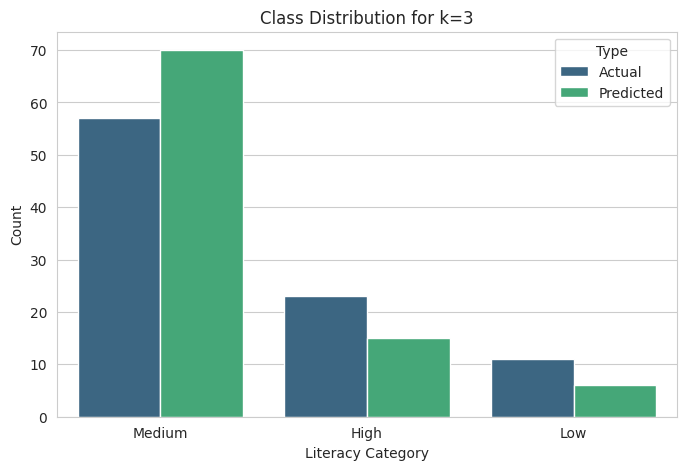

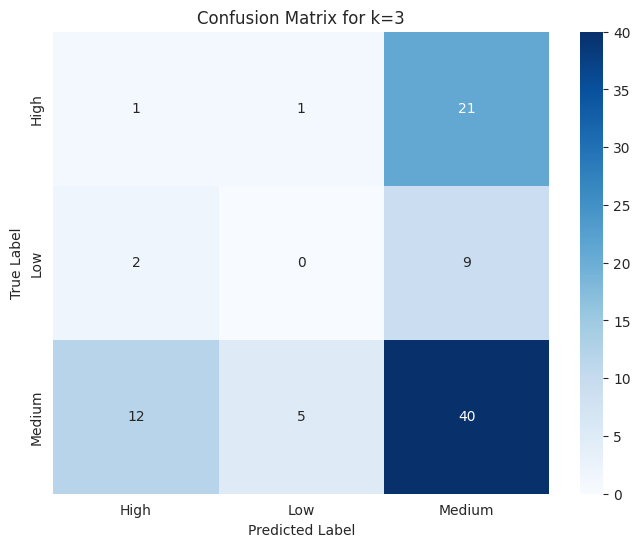

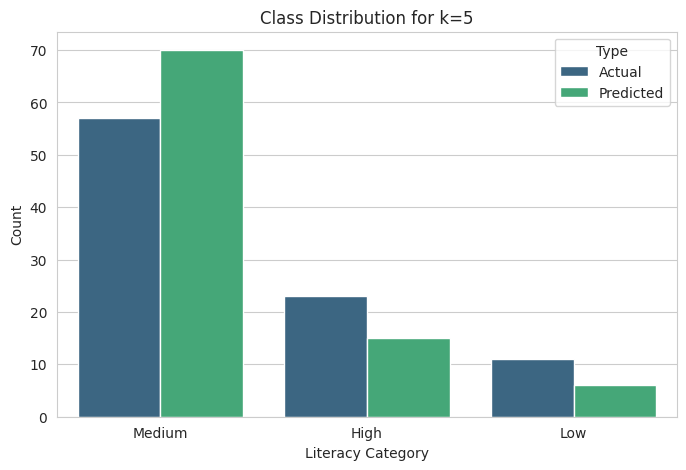

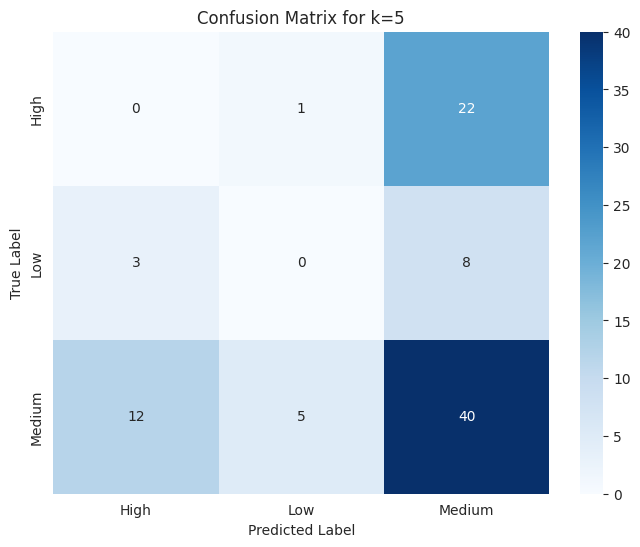

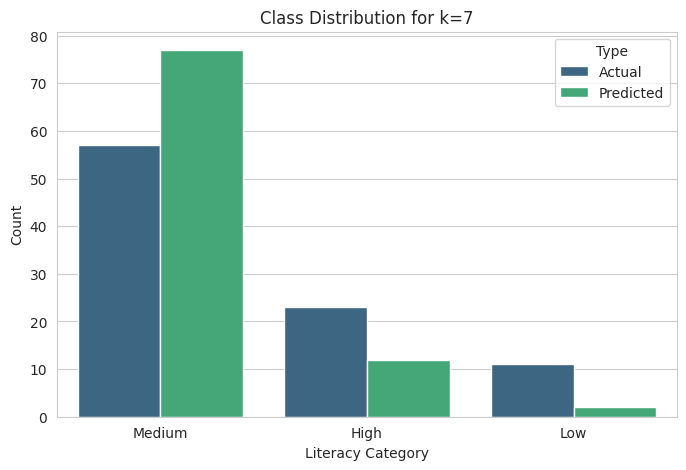

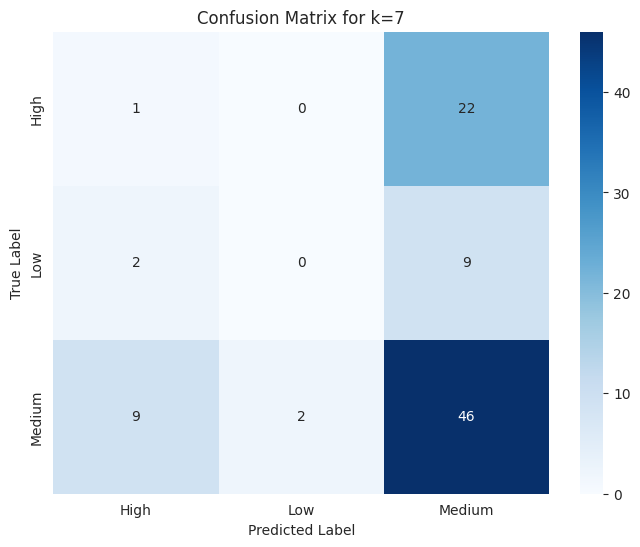

In [40]:
from sklearn.metrics import confusion_matrix

def plot_class_distribution(y_true, y_pred, title):
    """Generates a count plot comparing the true and predicted class distributions."""
    plt.figure(figsize=(8, 5))
    y_true_df = pd.DataFrame({'Literacy_Category': y_true, 'Type': 'Actual'})
    y_pred_df = pd.DataFrame({'Literacy_Category': y_pred, 'Type': 'Predicted'})
    combined_df = pd.concat([y_true_df, y_pred_df])
    sns.countplot(data=combined_df, x='Literacy_Category', hue='Type', palette='viridis')
    plt.title(title)
    plt.xlabel("Literacy Category")
    plt.ylabel("Count")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes, title):
    """Generates a heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

k_values = [3, 5, 7]
classes = np.unique(y_train_knn) # Get all possible classes from training data

for k in k_values:
    y_pred_val_knn = knn_predict(X_train_knn, y_train_knn, X_val_knn, k)

    plot_class_distribution(y_val_knn, y_pred_val_knn, f'Class Distribution for k={k}')
    plot_confusion_matrix(y_val_knn, y_pred_val_knn, classes, f'Confusion Matrix for k={k}')


## Implement k-fold cross-validation

### Subtask:
Implement k-fold cross-validation from scratch to assess the model's stability and performance across different subsets of the training data.


In [44]:
def kfold_cross_validation(n_splits, X_train, y_train, k_knn):
    """Performs k-fold cross-validation for the KNN model."""
    # Custom implementation of KFold
    fold_size = len(X_train) // n_splits
    accuracy_scores = []
    classes = np.unique(y_train)
    precision_scores = {cls: [] for cls in classes}
    recall_scores = {cls: [] for cls in classes}
    f1_scores = {cls: [] for cls in classes}

    indices = np.arange(len(X_train))
    np.random.shuffle(indices) # Shuffle indices for random folds

    for i in range(n_splits):
        val_indices = indices[i * fold_size : (i + 1) * fold_size]
        train_indices = np.setdiff1d(indices, val_indices)

        X_train_fold, X_val_fold = X_train[train_indices], X_train[val_indices]
        y_train_fold, y_val_fold = y_train[train_indices], y_train[val_indices]

        # Predict on the validation fold using the custom KNN
        y_pred_val_fold = knn_predict(X_train_fold, y_train_fold, X_val_fold, k_knn)

        # Evaluate the fold's performance using custom metric functions
        accuracy = calculate_accuracy(y_val_fold, y_pred_val_fold)
        accuracy_scores.append(accuracy)

        for class_label in classes:
            precision, recall, f1 = calculate_precision_recall_f1(y_val_fold, y_pred_val_fold, class_label)
            precision_scores[class_label].append(precision)
            recall_scores[class_label].append(recall)
            f1_scores[class_label].append(f1)


    print(f"K-Fold Cross-Validation Results for k_knn = {k_knn} ({n_splits} splits):")
    print(f"  Average Accuracy: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")

    print("  Average Metrics per Class:")
    for class_label in classes:
         print(f"    Class '{class_label}':")
         print(f"      Precision: {np.mean(precision_scores[class_label]):.4f} ± {np.std(precision_scores[class_label]):.4f}")
         print(f"      Recall: {np.mean(recall_scores[class_label]):.4f} ± {np.std(recall_scores[class_label]):.4f}")
         print(f"      F1-score: {np.mean(f1_scores[class_label]):.4f} ± {np.std(f1_scores[class_label]):.4f}")


# Perform k-fold cross-validation for different k values
k_values_knn = [3, 5, 7]
n_splits = 5

for k_knn in k_values_knn:
    kfold_cross_validation(n_splits, X_train_knn, y_train_knn, k_knn)

K-Fold Cross-Validation Results for k_knn = 3 (5 splits):
  Average Accuracy: 0.4871 ± 0.0346
  Average Metrics per Class:
    Class 'High':
      Precision: 0.2612 ± 0.0894
      Recall: 0.2251 ± 0.0546
      F1-score: 0.2402 ± 0.0685
    Class 'Low':
      Precision: 0.1122 ± 0.0798
      Recall: 0.0793 ± 0.0464
      F1-score: 0.0922 ± 0.0579
    Class 'Medium':
      Precision: 0.6126 ± 0.0338
      Recall: 0.6754 ± 0.0331
      F1-score: 0.6420 ± 0.0286
K-Fold Cross-Validation Results for k_knn = 5 (5 splits):
  Average Accuracy: 0.5482 ± 0.1123
  Average Metrics per Class:
    Class 'High':
      Precision: 0.3244 ± 0.1962
      Recall: 0.1511 ± 0.0518
      F1-score: 0.2012 ± 0.0845
    Class 'Low':
      Precision: 0.0686 ± 0.0859
      Recall: 0.0600 ± 0.0800
      F1-score: 0.0635 ± 0.0820
    Class 'Medium':
      Precision: 0.6243 ± 0.0955
      Recall: 0.8057 ± 0.1002
      F1-score: 0.7009 ± 0.0907
K-Fold Cross-Validation Results for k_knn = 7 (5 splits):
  Average Accura

In [45]:
def kfold_cross_validation(n_splits, X_train, y_train, k_knn):
    """Performs k-fold cross-validation for the KNN model."""
    # Custom implementation of KFold
    fold_size = len(X_train) // n_splits
    accuracy_scores = []
    classes = np.unique(y_train)
    precision_scores = {cls: [] for cls in classes}
    recall_scores = {cls: [] for cls in classes}
    f1_scores = {cls: [] for cls in classes}

    indices = np.arange(len(X_train))
    np.random.shuffle(indices) # Shuffle indices for random folds

    for i in range(n_splits):
        val_indices = indices[i * fold_size : (i + 1) * fold_size]
        train_indices = np.setdiff1d(indices, val_indices)

        X_train_fold, X_val_fold = X_train[train_indices], X_train[val_indices]
        y_train_fold, y_val_fold = y_train[train_indices], y_train[val_indices]


        # Predict on the validation fold using the custom KNN
        y_pred_val_fold = knn_predict(X_train_fold, y_train_fold, X_val_fold, k_knn)

        # Evaluate the fold's performance using custom metric functions
        accuracy = calculate_accuracy(y_val_fold, y_pred_val_fold)
        accuracy_scores.append(accuracy)


        for class_label in classes:
            precision, recall, f1 = calculate_precision_recall_f1(y_val_fold, y_pred_val_fold, class_label)
            precision_scores[class_label].append(precision)
            recall_scores[class_label].append(recall)
            f1_scores[class_label].append(f1)


    print(f"K-Fold Cross-Validation Results for k_knn = {k_knn} ({n_splits} splits):")
    print(f"  Average Accuracy: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")

    print("  Average Metrics per Class:")
    for class_label in classes:
         print(f"    Class '{class_label}':")
         print(f"      Precision: {np.mean(precision_scores[class_label]):.4f} ± {np.std(precision_scores[class_label]):.4f}")
         print(f"      Recall: {np.mean(recall_scores[class_label]):.4f} ± {np.std(recall_scores[class_label]):.4f}")
         print(f"      F1-score: {np.mean(f1_scores[class_label]):.4f} ± {np.std(f1_scores[class_label]):.4f}")


# Perform k-fold cross-validation for different k values
k_values_knn = [3, 5, 7]
n_splits = 5

for k_knn in k_values_knn:
    kfold_cross_validation(n_splits, X_train_knn, y_train_knn, k_knn)

K-Fold Cross-Validation Results for k_knn = 3 (5 splits):
  Average Accuracy: 0.5106 ± 0.0664
  Average Metrics per Class:
    Class 'High':
      Precision: 0.3026 ± 0.1148
      Recall: 0.2485 ± 0.0743
      F1-score: 0.2670 ± 0.0804
    Class 'Low':
      Precision: 0.1067 ± 0.1025
      Recall: 0.0633 ± 0.0577
      F1-score: 0.0745 ± 0.0685
    Class 'Medium':
      Precision: 0.6188 ± 0.1107
      Recall: 0.7044 ± 0.0218
      F1-score: 0.6527 ± 0.0671
K-Fold Cross-Validation Results for k_knn = 5 (5 splits):
  Average Accuracy: 0.5529 ± 0.0268
  Average Metrics per Class:
    Class 'High':
      Precision: 0.2811 ± 0.1044
      Recall: 0.1891 ± 0.0847
      F1-score: 0.2243 ± 0.0934
    Class 'Low':
      Precision: 0.1000 ± 0.2000
      Recall: 0.0167 ± 0.0333
      F1-score: 0.0286 ± 0.0571
    Class 'Medium':
      Precision: 0.6395 ± 0.0190
      Recall: 0.8047 ± 0.0400
      F1-score: 0.7118 ± 0.0132
K-Fold Cross-Validation Results for k_knn = 7 (5 splits):
  Average Accura

## Final evaluation on test set

### Subtask:
After selecting the best k based on cross-validation, evaluate the final model on the independent test set using appropriate classification metrics.


**Reasoning**:
Evaluate the KNN model on the independent test set using the best k found from cross-validation.



In [43]:
best_k = 7
y_pred_test_knn = knn_predict(X_train_knn, y_train_knn, X_test_knn, best_k)
accuracy_test = calculate_accuracy(y_test_knn, y_pred_test_knn)

print(f"Final KNN Model Evaluation on Test Set (k={best_k}):")
print(f"  Overall Accuracy: {accuracy_test:.4f}")

# Evaluate and print metrics for each class
classes_test = np.unique(y_test_knn)
for class_label in classes_test:
    precision, recall, f1 = calculate_precision_recall_f1(y_test_knn, y_pred_test_knn, class_label)
    print(f"  Metrics for class '{class_label}':")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall: {recall:.4f}")
    print(f"    F1-score: {f1:.4f}")

Final KNN Model Evaluation on Test Set (k=7):
  Overall Accuracy: 0.5761
  Metrics for class 'High':
    Precision: 0.2941
    Recall: 0.2174
    F1-score: 0.2500
  Metrics for class 'Low':
    Precision: 0.0000
    Recall: 0.0000
    F1-score: 0.0000
  Metrics for class 'Medium':
    Precision: 0.6486
    Recall: 0.8276
    F1-score: 0.7273


## Summary:

### Data Analysis Key Findings

*   The literacy rates were successfully categorized into 'Low' (\< 60), 'Medium' (60-80), and 'High' (\>= 80). The distribution showed 382 districts in 'Medium', 153 in 'High', and 75 in 'Low'.
*   The data was split into training (427 samples), validation (91 samples), and test (92 samples) sets with stratification based on the literacy categories.
*   A K-Nearest Neighbors (KNN) algorithm was implemented from scratch, including functions for Euclidean distance calculation, neighbor finding, and class prediction.
*   Evaluating the KNN model on the validation set for k=3, 5, and 7 showed varying accuracies: 0.4505 for k=3, 0.4396 for k=5, and 0.5165 for k=7.
*   For all tested k values on the validation set, the model achieved 0 precision, recall, and F1-score for the 'Low' literacy rate class.
*   K-fold cross-validation (5 splits) on the training data indicated that k=7 had the best average accuracy (0.5386 ± 0.0373).
*   The final evaluation on the independent test set with the chosen best k=7 resulted in an overall accuracy of 0.5761.
*   On the test set with k=7, the model still failed to correctly predict any instances of the 'Low' literacy category, resulting in 0.0000 for precision, recall, and F1-score for this class.

### Insights or Next Steps

*   The KNN model, using only 'Population', 'Growth', and 'Sex-Ratio' as features, struggles significantly with predicting the 'Low' literacy category. Feature engineering or including more relevant features might be necessary to improve performance for this class.
*   Investigate alternative distance metrics or explore data balancing techniques (like oversampling the 'Low' class) to address the poor performance on the minority 'Low' literacy category.
